# Credit Risk Prediction

With the increasing adoption of credit cards and digital payment systems, accurate credit risk prediction is essential to manage default risk and promote responsible lending. This project uses the **Default of Credit Card Clients dataset** from the UC Irvine Machine Learning Repository to analyze factors that influence whether a credit card holder will default on their payment.

The dataset provides variables that reflect common assessment factors used by Philippine banks, such as demographic information, credit limits, billing amounts, and past payments.

The goal of this project is to develop a predictive model that determines the probability of a credit card holder to default on their payment by analyzing patterns in financial behavior and customer characteristics, aiming to support better credit risk assessment and informed decisions.

*The supervised machine learning task to be performed, in the format: “Predict Y based on X ”, where Y is the target variable to be predicted, and X is the target list of features to be used for prediction.*

*Short justification (1–2 sentences) on why the task is interesting to the group members*

## Dataset Description

This project uses the **Default of Credit Card Clients Dataset** from the UCI Machine Learning Repository. The dataset contains information on credit card clients and their payment behavior, and it is commonly used for credit risk prediction tasks.

The dataset contains **30,000 observations** with **24 attributes** (23 features, 1 target variable). The attributes are as following:

`X1` or `LIMIT_BAL`: Amount of the given credit (NT dollar), including both the individual consumer credit and his/her family (supplementary credit)

`X2` or `SEX`: Gender of the client (1 = male; 2 = female)

`X3` or `EDUCATION`: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others)

`X4` or `MARRIAGE`: Marital status (1 = married; 2 = single; 3 = others)

`X5` or `AGE`: Age in years

`X6 - X11` represents the history of past payments from April to September of 2005

| Value | Meaning |
|-------|---------|
| -2    | Client had no bill that month |
| -1    | Paid early / fully paid in advance |
| 0     | Paid on time (no delay) |
| 1     | Payment delayed 1 month |
| 2     | Payment delayed 2 months |
| 3     | Payment delayed 3 months |
| 4     | Payment delayed 4 months |
| 5     | Payment delayed 5 months |
| 6     | Payment delayed 6 months |
| 7     | Payment delayed 7 months |
| 8     | Payment delayed 8 months |
| 9     | Payment delayed 9 months or more |

`X6` or `PAY_0`: Repayment status in September 2005

`X7` or `PAY_2`: Repayment status in August 2005

`X8` or `PAY_3`: Repayment status in July 2005

`X9` or `PAY_4`: Repayment status in June 2005

`X10` or `PAY_5`: Repayment status in May 2005

`X11` or `PAY_6`: Repayment status in April 2005

`X12 - X17` represents the amount of bill statements (NT dollar) from April to September of 2005

`X12` or `BILL_AMT1`: Amount of bill statement in September 2005

`X13` or `BILL_AMT2`: Amount of bill statement in August 2005

`X14` or `BILL_AMT3`: Amount of bill statement in July 2005

`X15` or `BILL_AMT4`: Amount of bill statement in June 2005

`X16` or `BILL_AMT5`: Amount of bill statement in May 2005

`X17` or `BILL_AMT6`: Amount of bill statement in April 2005

`X18 - X23` represents the amount of previous payments (NT dollar) from April to September of 2005

`X18` or `PAY_AMT1`: Amount paid in September 2005

`X19` or `PAY_AMT2`: Amount paid in August 2005

`X20` or `PAY_AMT3`: Amount paid in July 2005

`X21` or `PAY_AMT4`: Amount paid in June 2005

`X22` or `PAY_AMT5`: Amount paid in May 2005

`X23` or `PAY_AMT6`: Amount paid in April 2005

`Y` or `default payment`: Indicates whether the client defaulted on the next payment (1 = yes; 0 = no)

## Data Preparation

### Imports

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Cleaning

We will load the dataset from the `.xls` file using **pandas**.
Since the dataset uses `X0` - `X23` and `Y` as the first row, we set `header=1` to correctly load the column names and improve readability.

We can also use `df.head()` to see how the data is structured and encoded.

In [56]:
df = pd.read_excel("default_of_credit_card_clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


We will drop the `ID` column since it is a unique identifier for each client and does not provide predictive information.

In [57]:
df = df.drop("ID", axis=1)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


We check the dataset for duplicate entries and remove them to ensure data quality.

In [58]:
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")
df = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {len(df)}")

Number of duplicate rows: 35
Number of rows after removing duplicates: 29965


#### Normalizing Repayment Status Values
 
We will fix the repayment status columns (`PAY_0, PAY_2 – PAY_6`) as follows:  
- `-2` (no bill that month) → 0  
- `-1` (paid duly) → 0  
- 0 and positive integers remain unchanged

This ensures that all on-time payments are represented as 0 and delays remain positive integers with larger values indicating larger delays.

It's important to note that this presents a risk of data bias as the model may learn that clients with certain features + zero bills are "safe," but this might not be realistic if the zero bill is due to lack of credit activity or other financial behaviors.

In [59]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df[pay_cols] = df[pay_cols].replace([-2, -1], 0)
df[pay_cols].head()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,2,2,0,0,0,0
1,0,2,0,0,0,2
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


## Exploratory Data Analysis (EDA)

We will perform EDA to understand feature distributions, correlations, detect missing values, and identify any irregularities in the dataset.

In [60]:
# Summary statistics
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000
mean,167442.005006,1.603738,1.853629,1.551877,35.487969,0.356416,0.320340,0.304288,0.258935,0.221625,0.226698,51283.009778,49236.366294,4.706792e+04,43313.329885,40358.334390,38917.012281,5670.099316,5.927983e+03,5231.688837,4831.617454,4804.897047,5221.498014,0.221258
std,129760.135222,0.489128,0.790411,0.521997,9.219459,0.760752,0.802064,0.790696,0.761200,0.717768,0.715483,73658.132403,71195.567392,6.937135e+04,64353.514373,60817.130623,59574.147742,16571.849467,2.305346e+04,17616.361124,15674.464538,15286.372298,17786.976864,0.415101
min,10000.000000,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3595.000000,3010.000000,2.711000e+03,2360.000000,1787.000000,1262.000000,1000.000000,8.500000e+02,390.000000,300.000000,261.000000,131.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22438.000000,21295.000000,2.013500e+04,19081.000000,18130.000000,17124.000000,2102.000000,2.010000e+03,1804.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67260.000000,64109.000000,6.020100e+04,54601.000000,50247.000000,49252.000000,5008.000000,5.000000e+03,4512.000000,4016.000000,4042.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000


`df.info()` allows us to view the high level information of the dataset.

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   29965 non-null  int64
 1   SEX                         29965 non-null  int64
 2   EDUCATION                   29965 non-null  int64
 3   MARRIAGE                    29965 non-null  int64
 4   AGE                         29965 non-null  int64
 5   PAY_0                       29965 non-null  int64
 6   PAY_2                       29965 non-null  int64
 7   PAY_3                       29965 non-null  int64
 8   PAY_4                       29965 non-null  int64
 9   PAY_5                       29965 non-null  int64
 10  PAY_6                       29965 non-null  int64
 11  BILL_AMT1                   29965 non-null  int64
 12  BILL_AMT2                   29965 non-null  int64
 13  BILL_AMT3                   29965 non-null  int64
 14  BILL_AMT4  

With this, we can see that there are no missing values as all columns have the correct number (29,965) of non-null entries

In [62]:
df.groupby('default payment next month').describe()

LIMIT_BAL                 ... PAY_AMT6          
                               count           mean  ...      75%       max
default payment next month                           ...                   
0                            23335.0  178084.508249  ...  4553.00  528666.0
1                             6630.0  129984.567119  ...  2984.25  345293.0

[2 rows x 184 columns]

Using the `groupby` function, we observe a moderate class imbalance in the target variable, with a ratio of approximately 3.5:1 between non-default and default cases. To mitigate potential bias toward the majority class, we will apply stratified splitting in the train-test split and class weighting during model training.

Let's create a correlation heatmap of the entire dataset to get a general overview of the data.

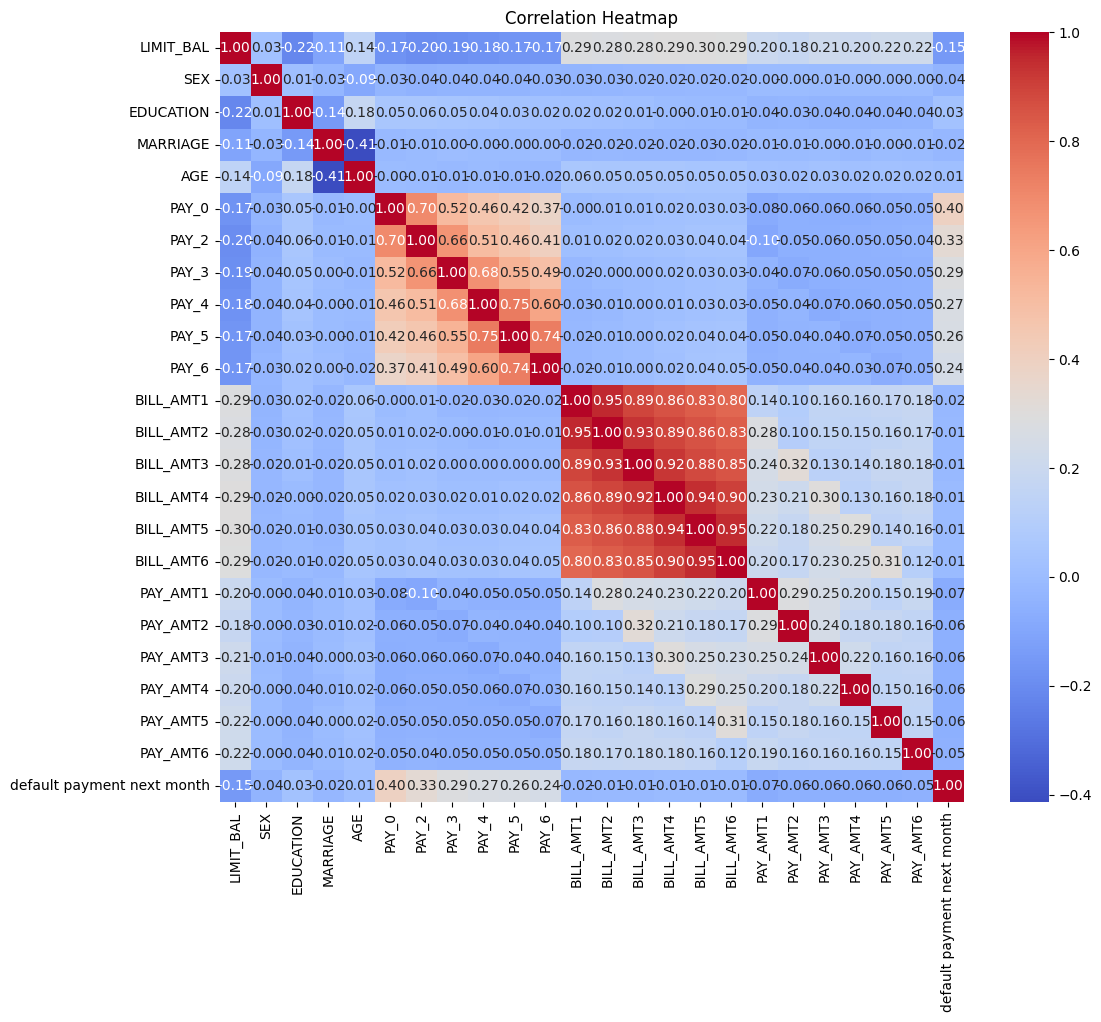

In [63]:
df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap reveals that the repayment status variables (`PAY_0` - `PAY_6`) exhibit the strongest positive correlations with the target variable, indicating that delayed repayments increase the likelihood of default. The correlations are decreasing for older repayment months, suggesting that more recent repayment behavior is a stronger predictor of default risk. We can also see strong correlation among all repayment status variables, which may suggest that clients' repayment behavior is consistent over time.

Billing amounts (`BILL-AMT1` - `BILL_AMT6`) are strongly correlated with each other, reflecting consistent spending patterns, but show minimal correlation with default. Payment amounts and demographic variables also show weak relationships with default.

Credit limit (`LIMIT_BAL`) has a weak negative relationship with default, which suggests that higher credit limits may be associated with slightly lower default probability. We can use a boxplot to visualize this more clearly.

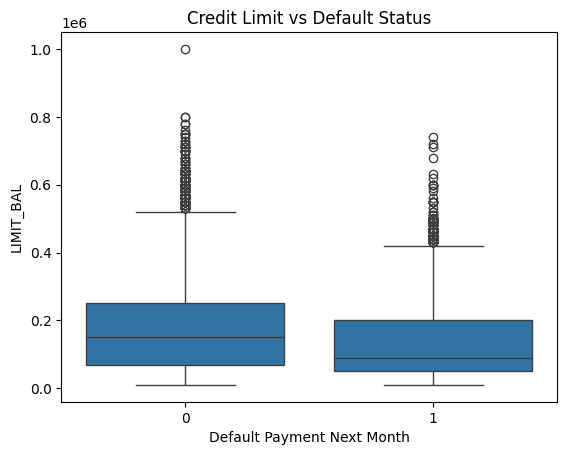

In [64]:
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default Status")
plt.xlabel("Default Payment Next Month")
plt.ylabel("LIMIT_BAL")
plt.show()

This boxplot suggests that clients who default tend to have lower credit limits compared to non-default clients.

*maybe add more EDA (visualizations) on the bill/pay amts, and demographic info*

## Data Preprocessing

### Feature Engineering

Based on the EDA, repayment status variables show the strongest relationship with default risk. These variables are also highly correlated with each other, suggesting consistent repayment behavior across months. 

To better capture overall repayment behavior and reduce redundancy among highly correlated variables, we engineer several summary features. These features aim to represent the client's repayment patterns more effectively than individual monthly variables alone.

#### Average Repayment Delay

The **average repayment delay** (`avg_pay_delay`) summarizes a cleint's overall repayment behavior across the six observed months. Higher values indicate that the client tends to delay their payments more frequently. This feature will capture the general tendency of a client to pay late.

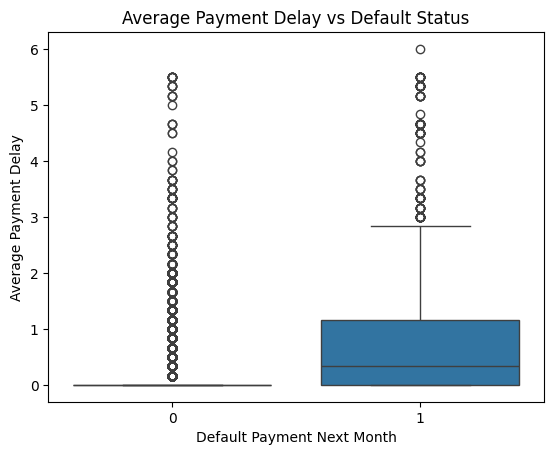

In [65]:
df["avg_pay_delay"] = df[pay_cols].mean(axis=1)

sns.boxplot(x='default payment next month', y='avg_pay_delay', data=df)
plt.title("Average Payment Delay vs Default Status")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Average Payment Delay")
plt.show()

#### Maximum Repayment Delay

The **maximum repayment delay** represents the worst repayment status recorded. This feature captures extreme repayment behavior, as a large delay in any month may indicate financial instability even if the client is usually on time.

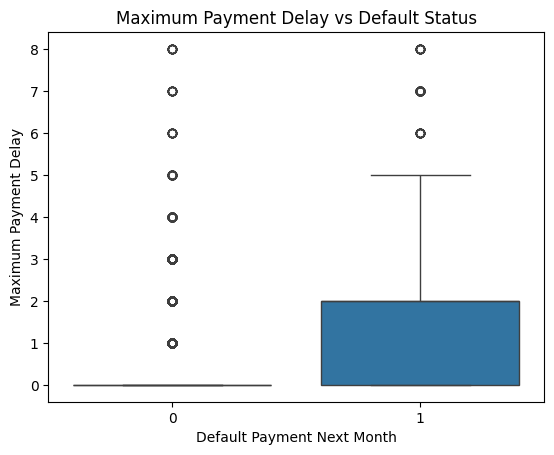

In [66]:
df["max_delay"] = df[pay_cols].max(axis=1)

sns.boxplot(x='default payment next month', y='max_delay', data=df)
plt.title("Maximum Payment Delay vs Default Status")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Maximum Payment Delay")
plt.show()

#### Number of Late Payments

The **number of late payments** counts how many months a client was late in making payments. This provides a simple measure of how frequently a client struggles to meet payment deadlines.

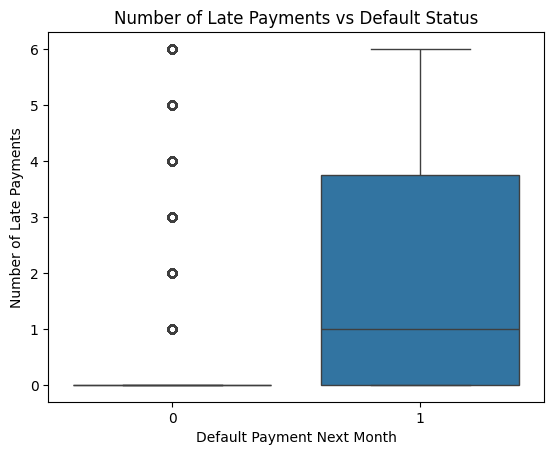

In [67]:
df["num_late_payments"] = (df[pay_cols] > 0).sum(axis=1)

sns.boxplot(x='default payment next month', y='num_late_payments', data=df)
plt.title("Number of Late Payments vs Default Status")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Late Payments")
plt.show()

#### Average Payment Ratio

The **average payment ratio** measures the average proportion of the bill that was paid during a given month. This gives us a clearer picture of a client's repayment behavior by comparing payment amounts to bill amounts. A lower ratio may indicate that the client is consistently paying only a small portion of their outstanding balance, which could signal a higher risk of default.

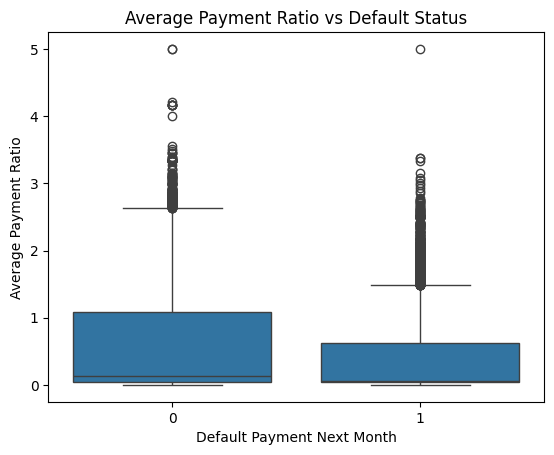

In [68]:
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

# Replace negative bills with 0 ONLY for ratio calculation
bill_positive = df[bill_cols].clip(lower=0)

monthly_ratios = df[pay_amt_cols].values / (bill_positive.values + 1)
avg_pay_ratio = monthly_ratios.mean(axis=1)
df["avg_pay_ratio"] = avg_pay_ratio

clipped_ratios = np.clip(monthly_ratios, 0, 5)  # Clip ratios for visualization
df["avg_pay_ratio_clipped"] = clipped_ratios.mean(axis=1)

sns.boxplot(x='default payment next month', y='avg_pay_ratio_clipped', data=df)
plt.title("Average Payment Ratio vs Default Status")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Average Payment Ratio")
plt.show()

df.drop(columns=["avg_pay_ratio_clipped"], inplace=True)

## Model Selection and Training

To predict the probability of a client to default on their credit card payment, we will first train a **Logistic Regression** model. Logistic Regression is commonly used as a baseline model for binary classification tasks due to its interpretability and efficiency. Instead of only predicting whether a client will default or not, the model can also estimate the **probability of default** for each client. Predicting probabilities provides more detailed information about the level of risk associated with each client.

However, logistic regression may not be able to capture complex patterns in the data due to its assumption of a linear relationship. To address this, a **Random Forest** model is also evaluated. ***insert info about random forest and why it's good for this***

Due to the class imbalance (approximately 3.5:1 ratio), we will implement the following strategies as stated previously:

1. **Stratified Train-Test Split**

2. **Class Weighting**

A stratified train-test split will ensure that both the train and test data maintain the same class distribution. We will also apply a higher weight to the minority class (default cases) to reduce bias towards predicting the majority class. 
*insert info about the split (70-10-20)*


In [69]:
from sklearn.model_selection import train_test_split

X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21574, 27)
y_train shape: (21574,)
X_val shape: (2398, 27)
y_val shape: (2398,)
X_test shape: (5993, 27)
y_test shape: (5993,)


### Feature Scaling

#### Standardization

We will perform standardization on the continuous variables in the training dataset, such as the bill and payment amounts, using `sklearn.preprocessing.StandardScaler`

We will use fit only on the training data to avoid data leakage, and transform on the validation and test data to ensure the data is scaled in the same way as the training data.

In [84]:
import sklearn.preprocessing

scaler = sklearn.preprocessing.StandardScaler()

# Amount columns
amount_cols = [col for col in df.columns if "AMT" in col]

X_train[amount_cols] = scaler.fit_transform(X_train[amount_cols])
X_val[amount_cols] = scaler.transform(X_val[amount_cols])
X_test[amount_cols] = scaler.transform(X_test[amount_cols])

X_train[amount_cols].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04,2.157400e+04
mean,-1.053925e-17,-2.321927e-17,-1.778498e-17,-2.173719e-17,8.563137e-18,-2.568941e-17,-1.020989e-17,-5.928325e-18,8.727812e-18,1.020989e-17,3.293514e-18,-2.634811e-18
std,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00
min,-2.960242e+00,-1.163400e+00,-2.933953e+00,-1.935261e+00,-1.672656e+00,-6.329516e+00,-3.344158e-01,-2.392195e-01,-2.963597e-01,-3.182932e-01,-3.167614e-01,-2.862406e-01
25%,-6.517005e-01,-6.520191e-01,-6.371496e-01,-6.363038e-01,-6.352337e-01,-6.318171e-01,-2.757415e-01,-2.049694e-01,-2.740778e-01,-2.987943e-01,-2.994710e-01,-2.790857e-01
50%,-3.896344e-01,-3.895317e-01,-3.854298e-01,-3.757690e-01,-3.650063e-01,-3.654816e-01,-2.110236e-01,-1.584894e-01,-1.932630e-01,-2.194813e-01,-2.185207e-01,-2.050890e-01
75%,2.246426e-01,2.113992e-01,1.874469e-01,1.775130e-01,1.659430e-01,1.738635e-01,-4.017854e-02,-3.839839e-02,-3.898928e-02,-5.267045e-02,-5.395111e-02,-6.983637e-02
max,1.246729e+01,1.314826e+01,2.320834e+01,1.316112e+01,1.456363e+01,1.542310e+01,5.092070e+01,6.740773e+01,5.089720e+01,4.058982e+01,2.705899e+01,2.831515e+01


We can see that all standardized columns have a mean ≈ 0 and a standard deviation ≈ 1.

Let's visualize the results in two histograms with KDE (Kernel Density Estimate). KDE allows us to visualize the probability distribution more smoothly. We set `bins=30` to divide the data into 30 intervals, providing a clear view of the distribution.

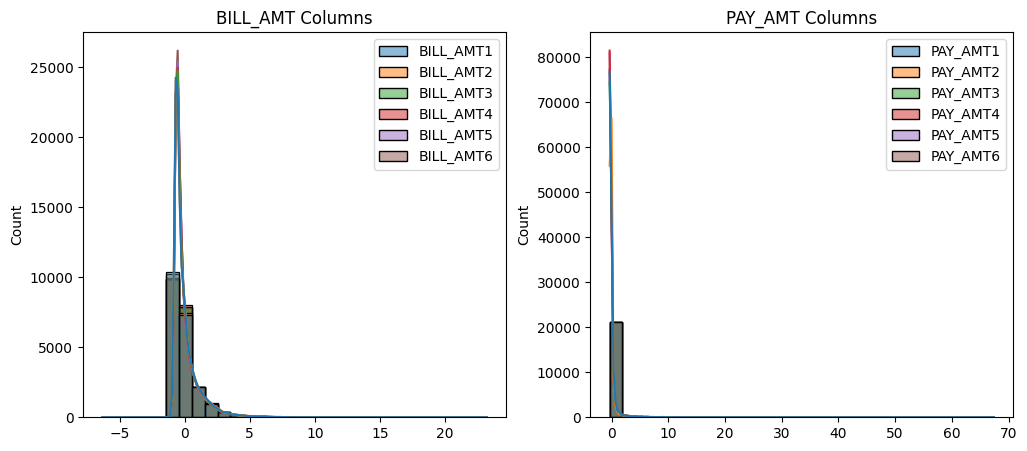

In [71]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(X_train[[col for col in amount_cols if "BILL" in col]], kde=True, bins=30)
plt.title("BILL_AMT Columns")

plt.subplot(1,2,2)
sns.histplot(X_train[[col for col in amount_cols if "PAY" in col]], kde=True, bins=30)
plt.title("PAY_AMT Columns")

plt.show()

We can see that all variables are centered around 0, as expected after standardization.

### Baseline Model: Logistic Regression Training

Using `class_weight="balanced"` will automatically adjust the weights based on the class frequencies.

In [72]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)

model.fit(X_train, y_train)

c:\Users\kiwik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


While we are focusing on the probability of default, we will still predict the label for evaluation purposes.

In [73]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
y_prob[:10]

array([0.37699576, 0.32115354, 0.33739828, 0.50745929, 0.28063961,
       0.26884187, 0.41692416, 0.27935462, 0.29246067, 0.22475332])

### Error Analysis

*yap about evaluation of model*

*note: accuracy and confusion matrix is for prediction of labels, the others r for evaluation of the predicted probabilities*

*up to u which metrics should we keep, im not sure whats important or wtv*


#### Accuracy and Classification Report

In [74]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7510428833639246

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4667
           1       0.45      0.60      0.52      1326

    accuracy                           0.75      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.75      0.76      5993



*analysis / interpretation*

#### Brier Score
A brier score is a way to verify the accuracy of a probability forecast, used for binary outcomes. Smaller scores (closer to 0) indicate better forecasts, while scores in the middle (close to 0.5) can be hard to interpret as either "good" or "bad."

In [75]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)
print("Brier Score (Logistic Regression):", brier)

Brier Score (Logistic Regression): 0.18899612252644338


*analysis / interpretation*

#### AUC-ROC Curve
AUC-ROC is effective if the dataset is balanced and the model needs to be evaluated across all thresholds. The AUC-ROC curve is a graph used to help understand how the model separates the positive cases from the negative cases at different threshold levels by plotting:
- True Positive Rate (TPR)
- False Positive Rate (FPR)
- Specificity (measures the proportion of actual negatives that the model correctly identifies, calculated as 1 - FPR)

A high AUC (close to 1) means that the model effectively distinguishes between the positive and negative classes, a low AUC (close to 0) indicates that the model struggles to differentiate the two classes, and an AUC around 0.5 suggests that the model does not learn any meaningful patterns and is doing random guessing.

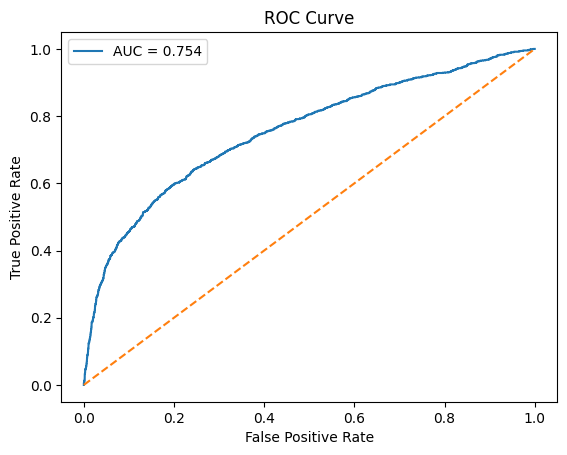

In [76]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

*analysis / interpretation*

While ROC-AUC remains a useful metric for evaluating ranking performance across thresholds, it may be optimistic in imbalanced settings. Therefore, we also use the precision-recall curve to focus on the positive class.

#### Precision-Recall Curve

The Precision-Recall Curve (PR Curve) allows us to understand how well the model is doing especially when the data is imbalanced. In this case, we have a 3.5:1 ratio of non-default to default cases. The PR curve focuses only on how the model handles the positive class (default). A higher AUC typically indicates better model performance.

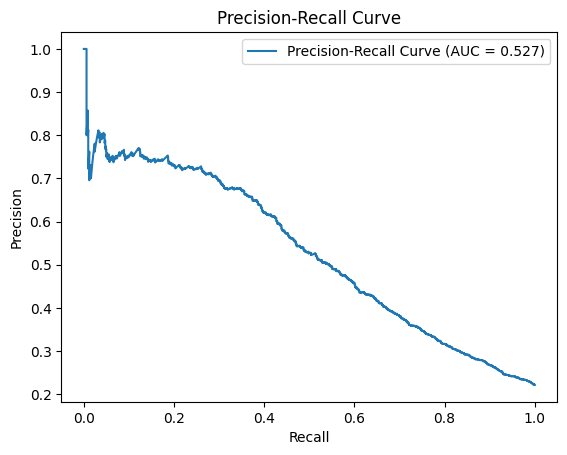

In [77]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
auc_score = auc(recall, precision)
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

*analysis*

#### Feature Importance
*brief description and importance*

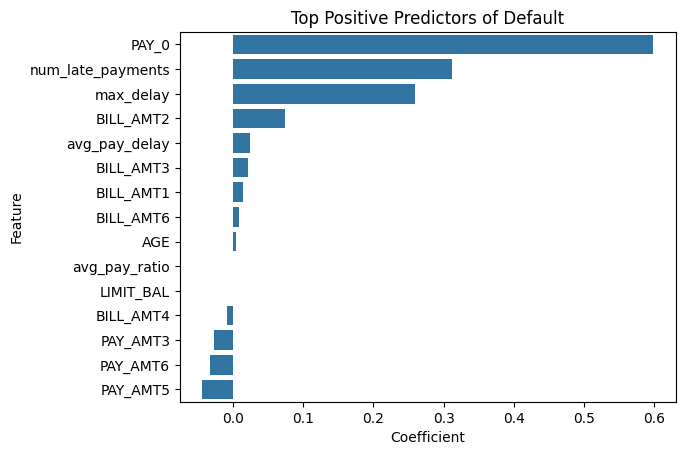

In [78]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coefficients.head(15)
)

plt.title("Top Positive Predictors of Default")
plt.show()

*meow*

## Random Forest Model Training

*put justification for hyperparameters (class_weight, n_estimators)*

In [79]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

## Error Analysis and Model Tuning

#### Accuracy and Classification Report

In [80]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

classification_report_rf = classification_report(y_test, y_pred_rf)
print("\nRandom Forest Classification Report:\n")
print(classification_report_rf)

Random Forest Accuracy: 0.809611213081929

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.94      0.89      4667
           1       0.63      0.34      0.44      1326

    accuracy                           0.81      5993
   macro avg       0.73      0.64      0.66      5993
weighted avg       0.79      0.81      0.79      5993



#### Brier Score

In [81]:
brier_rf = brier_score_loss(y_test, y_prob_rf)
print("Brier Score (Random Forest):", brier_rf)

Brier Score (Random Forest): 0.14036675839166946


*analysis*

#### AUC-ROC Curve

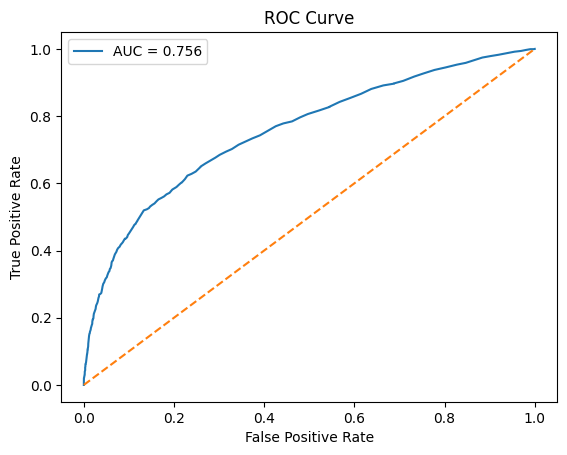

In [82]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

*analysis*

#### Precision-Recall Curve

In [83]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)
auc_score = auc(recall, precision)
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

TypeError: 'float' object is not callable

#### Feature Importance


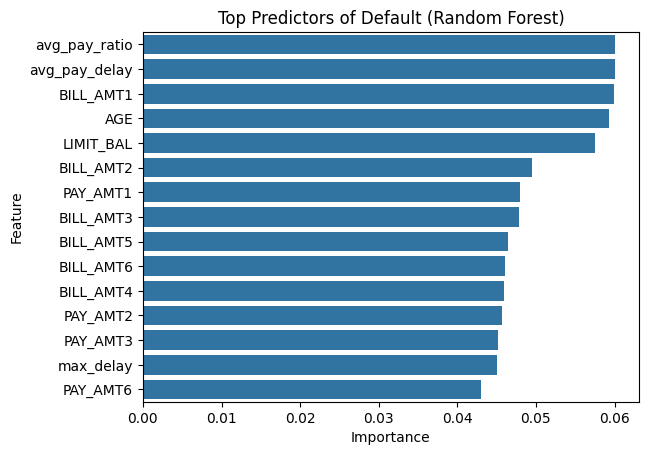

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15)
)
plt.title("Top Predictors of Default (Random Forest)")
plt.show()

*analysis*


### Hyperparameter Tuning

*justification for what metric to optimize (pr-auc)*

#### Parameters
*the most important random forest hyperparameters (put justification n stuff as to why), also put what each parameter is*

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None]}

*RandomizedSearchCV*

## Model Evaluation

Sources

https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc

https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/